# Online Retail Customer Value Analysis – A Simple Data Product

## Outline

1. **Product Overview**  
2. **Import Libraries and Load Data**  
3. **Data Loading and Initial Inspection**  
4. **Data Cleaning and Preparation**  
5. **Analysis**  
6. **Insight Generation**  
7. **Recommendation Engine (Decision Support Layer)**  
8. **Appendix: Limitations and Other Notes**

## 1. Product Overview

This project develops a simple Python-based **customer value analysis tool** for small and medium-sized e-commerce businesses.  
Using transaction-level sales data, the workflow identifies high-value customers, evaluates revenue concentration, detects sales patterns, and generates basic business recommendations.  
The Online Retail dataset is used as a **demonstration case**.

#### Analytical Purpose
The product is designed to answer three business questions:

1. Who are the most valuable customers?  
2. How is revenue distributed across customers?  
3. What time and geographic patterns support business performance?  

#### Target User and Value
The target users are small e-commerce business owners and beginner analysts who have transaction data but lack advanced data analysis skills.  
This product helps them turn raw sales records into interpretable results for decision-making. Its value lies in reducing manual analysis time, lowering technical barriers, and producing clear business insights and simple recommendations.


### 1.1 Product Requirements
To run this workflow, the dataset should contain transaction-level records with at least:

- a customer identifier  
- a transaction date  
- a quantity variable  
- a unit price or transaction value  
- an optional country or region variable  

Column names do not need to match exactly, but they should be mapped to a standard structure before analysis:

| Standard Variable | Description |
|------------------|------------|
| `customer_id` | Unique identifier for each customer |
| `transaction_date` | Date of purchase |
| `quantity` | Number of items purchased |
| `unit_price` | Price per unit |
| `country` | Customer location (optional) |

This workflow assumes that each row represents a transaction record and that invalid records such as returns, cancellations, or non-positive values are removed or handled during cleaning.

### 1.2 Demonstration Dataset

The Online Retail dataset is used to demonstrate the workflow.  
It contains transaction-level retail records such as invoice number, quantity, transaction date, unit price, customer ID, and country.  
Because it includes the core fields required for customer-level and sales-pattern analysis, it is suitable for this project.  
The dataset was obtained from the UCI Machine Learning Repository (*Online Retail*), accessed on 2026.4.15.
Accessed at：https://archive.ics.uci.edu/dataset/352/online%2Bretail?utm_source


### 1.3 Notebook Structure

This notebook is organised into three main parts.  
First, it defines the product purpose and input requirements.  
Second, it performs data cleaning and analysis on the demonstration dataset.  
Finally, it converts analytical outputs into automated insights and business recommendations.

Readers who want to focus on the main results may refer directly to **Section 6: Insight Generation** and **Section 7: Recommendation Engine**, while **Section 5: Analysis** provides the supporting metrics and visual evidence.


## 2. Import Libraries and Load Data
The following Python libraries are used for data loading, cleaning, aggregation, and visualisation.

In [2]:
#import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "Online Retail.xlsx"

df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Initial Inspection

In this section, I load the dataset and inspect its basic structure, including the first few rows, number of rows and columns, column names, data types, and missing values.

In [3]:
df.shape

(541909, 8)

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": df.isna().mean() * 100
})

missing_summary.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
InvoiceNo,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


### Initial Observation

From the initial inspection, the dataset contains transaction-level sales records with variables related to products, customers, prices, and dates.

At this stage, several issues require attention:
- `CustomerID` contains a large number of missing values
- `InvoiceDate` needs to be converted into datetime format for time-based analysis
- a revenue variable needs to be created
- invalid records such as non-positive quantity or non-positive unit price need to be examined

These steps are necessary before conducting further analysis.

## 4. Data Cleaning and Preparation

In this section, I clean the dataset and prepare it for analysis. This includes handling missing values, converting date variables, removing clearly invalid records, and creating new variables such as revenue and time-based features.

In [8]:
# Create a copy to avoid modifying the original dataset
df_clean = df.copy()

In [9]:
## Convert the transaction date to datetime format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

In [10]:
#Create a revenue variable: Revenue = Quantity × UnitPrice
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [11]:
#Create time-based variables for later analysis
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

In [12]:
# Inspect the distribution of key numeric variables
df_clean[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,17.987795
std,218.081158,96.759853,378.810824
min,-80995.000000,-11062.060000,-168469.600000
25%,1.000000,1.250000,3.400000
50%,3.000000,2.080000,9.750000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


In [13]:
# Count invalid or missing records
invalid_quantity = (df_clean["Quantity"] <= 0).sum()
invalid_price = (df_clean["UnitPrice"] <= 0).sum()
missing_customer = df_clean["CustomerID"].isna().sum()

print("Invalid Quantity <= 0:", invalid_quantity)
print("Invalid UnitPrice <= 0:", invalid_price)
print("Missing CustomerID:", missing_customer)

Invalid Quantity <= 0: 10624
Invalid UnitPrice <= 0: 2517
Missing CustomerID: 135080


In [14]:
## Remove records that are not suitable for customer value analysis
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Check the cleaned dataset
df_clean.shape

(397884, 12)

### Cleaning Rules

Since the product is designed to analyse valid purchase behaviour, records with missing `CustomerID`, non-positive `Quantity`, or non-positive `UnitPrice` are removed during cleaning.

This ensures that the later analysis focuses on identifiable and valid purchase transactions rather than returns, cancellations, or invalid entries.


In [15]:

df_clean = df.copy()

# Remove records with missing customer IDs
df_clean = df_clean.dropna(subset=["CustomerID"])

## Remove records with non-positive quantity or unit price
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [16]:
# Check the result after cleaning
df_clean.shape
df_clean[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


### Cleaning Check

After cleaning, the dataset contains only records with positive `Quantity` and `UnitPrice`, making it suitable for customer-level purchase analysis.

## 5.Analysis
### 5.1 Customer-Level Analysis
This step calculates customer-level revenue and order metrics.

In [17]:

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Aggregate transaction data at the customer level
customer_summary = df_clean.groupby("CustomerID").agg(
    TotalRevenue=("Revenue", "sum"),
    Transactions=("InvoiceNo", "nunique"),
    TotalQuantity=("Quantity", "sum")
).reset_index()

# Calculate average order value
customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] / customer_summary["Transactions"])

customer_summary.head()



,CustomerID,TotalRevenue,Transactions,TotalQuantity,AverageOrderValue
0,12346.0,77183.60,1,74215,77183.600000
1,12347.0,4310.00,7,2458,615.714286
2,12348.0,1797.24,4,2341,449.310000
3,12349.0,1757.55,1,631,1757.550000
4,12350.0,334.40,1,197,334.400000


In [18]:
# Identify the top 10 customers by total revenue
top_10_customers = customer_summary.sort_values(
    by="TotalRevenue", ascending=False
).head(10)

top_10_customers

,CustomerID,TotalRevenue,Transactions,TotalQuantity,AverageOrderValue
1689,14646.0,280206.02,73,196915,3838.438630
4201,18102.0,259657.30,60,64124,4327.621667
3728,17450.0,194550.79,46,69993,4229.365000
3008,16446.0,168472.50,2,80997,84236.250000
1879,14911.0,143825.06,201,80265,715.547562
55,12415.0,124914.53,21,77374,5948.310952
1333,14156.0,117379.63,55,57885,2134.175091
3771,17511.0,91062.38,31,64549,2937.496129
2702,16029.0,81024.84,63,40208,1286.108571
0,12346.0,77183.60,1,74215,77183.600000


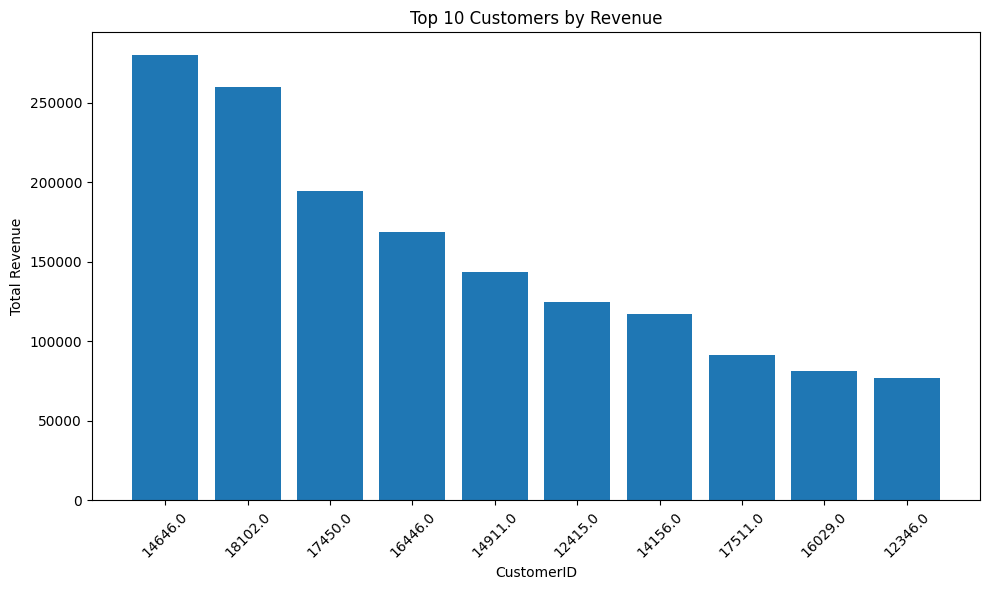

In [19]:
# Visualise the top 10 customers by revenue
plt.figure(figsize=(10, 6))
plt.bar(top_10_customers["CustomerID"].astype(str), top_10_customers["TotalRevenue"])
plt.xticks(rotation=45)
plt.xlabel("CustomerID")
plt.ylabel("Total Revenue")
plt.title("Top 10 Customers by Revenue")
plt.tight_layout()
plt.show()

### 5.2 Revenue Concentration
After identifying the most valuable customers, the next step is to examine whether revenue is concentrated among a small group of customers.



In [20]:
# Sort customers by revenue in descending order
customer_sorted = customer_summary.sort_values(
    by="TotalRevenue", ascending=False
).reset_index(drop=True)

# Calculate the cumulative revenue share
customer_sorted["CumulativeRevenue"] = customer_sorted["TotalRevenue"].cumsum()
customer_sorted["CumulativeRevenueShare"] = (
    customer_sorted["CumulativeRevenue"] / customer_sorted["TotalRevenue"].sum())

# Calculate the revenue share of the top 10, 20, and 50 customers
top_10_share = customer_sorted.head(10)["TotalRevenue"].sum() / customer_sorted["TotalRevenue"].sum()
top_20_share = customer_sorted.head(20)["TotalRevenue"].sum() / customer_sorted["TotalRevenue"].sum()
top_50_share = customer_sorted.head(50)["TotalRevenue"].sum() / customer_sorted["TotalRevenue"].sum()

print("Top 10 customer revenue share:", round(top_10_share * 100, 2), "%")
print("Top 20 customer revenue share:", round(top_20_share * 100, 2), "%")
print("Top 50 customer revenue share:", round(top_50_share * 100, 2), "%")

Top 10 customer revenue share: 17.26 %
Top 20 customer revenue share: 23.86 %
Top 50 customer revenue share: 33.23 %


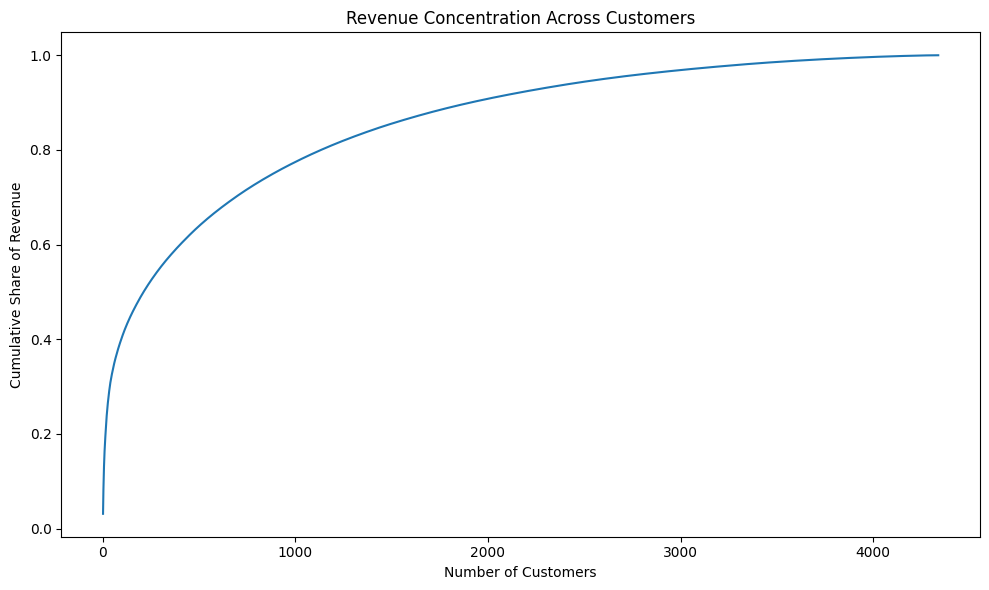

In [21]:
# 画 cumulative share 图
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(customer_sorted) + 1),
    customer_sorted["CumulativeRevenueShare"]
)
plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Share of Revenue")
plt.title("Revenue Concentration Across Customers")
plt.tight_layout()
plt.show()

### 5.3 Monthly Pattern
Beyond customer-level patterns, it is also important to understand how sales change over time.

In [22]:
# Ensure that InvoiceDate is in datetime format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

# 创建时间变量
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

# Create time-based variables
df_clean[["InvoiceDate", "Year", "Month", "YearMonth"]].head()

,InvoiceDate,Year,Month,YearMonth
0,2010-12-01 08:26:00,2010,12,2010-12
1,2010-12-01 08:26:00,2010,12,2010-12
2,2010-12-01 08:26:00,2010,12,2010-12
3,2010-12-01 08:26:00,2010,12,2010-12
4,2010-12-01 08:26:00,2010,12,2010-12


In [29]:
# Aggregate revenue by month
monthly_sales = df_clean.groupby("YearMonth").agg(
    MonthlyRevenue=("Revenue", "sum")
).reset_index()

monthly_sales

# Calculate peak month share
max_month_revenue = monthly_sales["MonthlyRevenue"].max()
total_revenue = monthly_sales["MonthlyRevenue"].sum()

peak_month_share = max_month_revenue / total_revenue

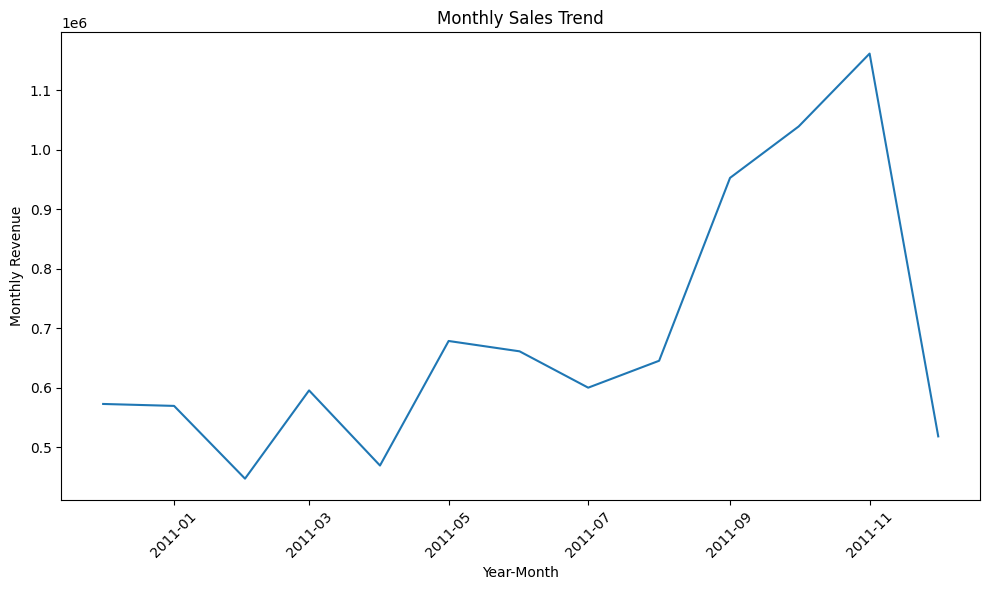

In [24]:
# Plot the monthly revenue trend
monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])
monthly_sales = monthly_sales.sort_values("YearMonth")

plt.figure(figsize=(10, 6))
plt.plot(monthly_sales["YearMonth"], monthly_sales["MonthlyRevenue"])
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Monthly Revenue")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

### 5.4 Country Pattern
In addition to customer and time patterns, geographic distribution provides another important perspective on revenue structure.

In [25]:
# Aggregate revenue by country
country_sales = df_clean.groupby("Country").agg(
    TotalRevenue=("Revenue", "sum")
).reset_index()

country_sales = country_sales.sort_values("TotalRevenue", ascending=False)

country_sales.head(10)

,Country,TotalRevenue
35,United Kingdom,7308391.554
23,Netherlands,285446.340
10,EIRE,265545.900
14,Germany,228867.140
13,France,209024.050
0,Australia,138521.310
30,Spain,61577.110
32,Switzerland,56443.950
3,Belgium,41196.340
31,Sweden,38378.330


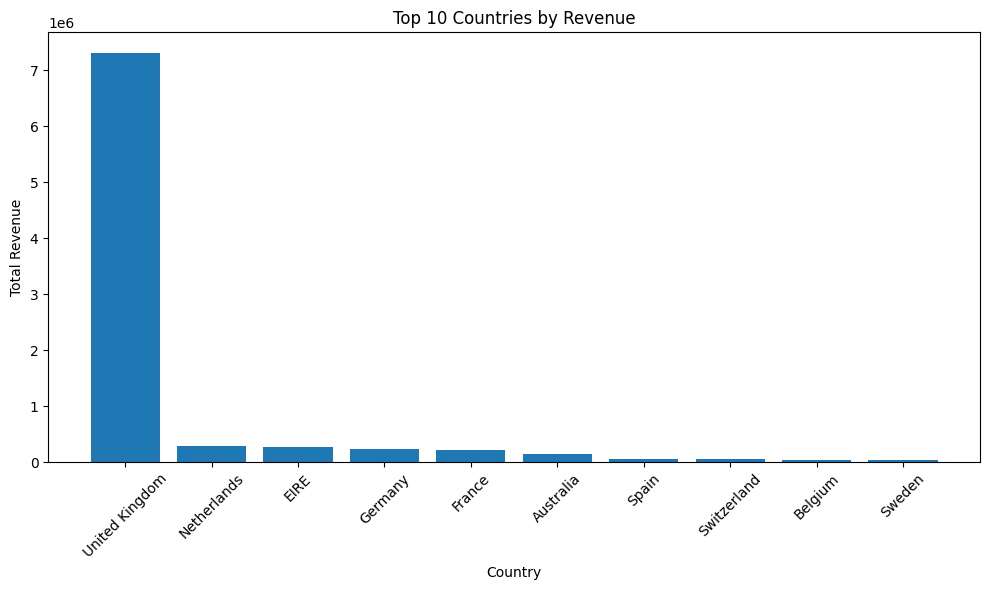

In [26]:
# Plot the top countries by revenue
top_10_countries = country_sales.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10_countries["Country"], top_10_countries["TotalRevenue"])
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 10 Countries by Revenue")
plt.tight_layout()
plt.show()

In [27]:
# Calculate the UK share of total revenue
uk_revenue = country_sales[country_sales["Country"] == "United Kingdom"]["TotalRevenue"].sum()
total_revenue = country_sales["TotalRevenue"].sum()
uk_share = uk_revenue / total_revenue

print("United Kingdom revenue share:", round(uk_share * 100, 2), "%")

United Kingdom revenue share: 82.01 %


## 6. Insight Generation

This section converts analytical metrics into structured insights using rule-based logic.

In [30]:
# Insight 1: Revenue concentration
if top_10_share >= 0.30:
    insight_1 = "Customer value is highly concentrated among a small group of customers."
else:
    insight_1 = "Customer value is relatively distributed across the customer base."

# Insight 2: Market dependence
if uk_share >= 0.70:
    insight_2 = "Revenue is highly dependent on a single country."
else:
    insight_2 = "Revenue is distributed across multiple countries."

# Insight 3: Seasonality
if peak_month_share >= 0.35:
    insight_3 = "Sales show strong seasonal patterns."
else:
    insight_3 = "Sales are relatively stable across time."

# Insight 4: Customer type pattern
# Compare frequent buyers with large-purchase customers
high_freq_customers = customer_summary[customer_summary["Transactions"] > 10]
bulk_customers = customer_summary[customer_summary["AverageOrderValue"] > 500]

frequent_buyer_ratio = len(high_freq_customers) / len(customer_summary)
bulk_buyer_ratio = len(bulk_customers) / len(customer_summary)

if frequent_buyer_ratio > bulk_buyer_ratio:
    insight_4 = "High-value customers are mainly frequent buyers."
else:
    insight_4 = "High-value customers are mainly driven by large purchases."

# Display the generated insights
print("Insights:")
print("-", insight_1)
print("-", insight_2)
print("-", insight_3)
print("-", insight_4)

Insights:
- Customer value is relatively distributed across the customer base.
- Revenue is highly dependent on a single country.
- Sales are relatively stable across time.
- High-value customers are mainly driven by large purchases.


## 7. Recommendation Engine (Decision Support Layer)

### Purpose

To enhance the usefulness of this data product, a rule-based recommendation system is introduced.

Instead of only presenting descriptive results, this section translates analytical outputs into **actionable business suggestions**.

These recommendations are generated based on key metrics derived from the analysis.

---

### Input Metrics

The following metrics from previous analysis are used:

- Top customer revenue share (e.g., top 10 share)
- Country revenue share (e.g., UK share)
- Monthly peak concentration
- Customer purchasing patterns (frequency vs bulk)


In [ ]:
# Recommendation 1
if top_10_share >= 0.30:
    suggestion_1 = "Focus on retaining top customers through loyalty programs."
else:
    suggestion_1 = "Develop broader customer engagement strategies."

# Recommendation 2
if uk_share >= 0.70:
    suggestion_2 = "Reduce reliance on a single market by expanding internationally."
else:
    suggestion_2 = "Maintain diversified market presence."

# Recommendation 3
if peak_month_share >= 0.35:
    suggestion_3 = "Prepare inventory and marketing before peak seasons."
else:
    suggestion_3 = "Maintain steady operational planning."

# Recommendation 4
if frequent_buyer_ratio > bulk_buyer_ratio:
    suggestion_4 = "Focus on repeat purchase strategies."
else:
    suggestion_4 = "Encourage bulk purchasing through pricing strategies."

# Display the business recommendations
print("\nBusiness Recommendations:")
print("-", suggestion_1)
print("-", suggestion_2)
print("-", suggestion_3)
print("-", suggestion_4)


Business Recommendations:
- Develop broader customer engagement strategies.
- Reduce reliance on a single market by expanding internationally.
- Maintain steady operational planning.
- Encourage bulk purchasing through pricing strategies.


## Appendix: Limitations and Other Notes

This project has several limitations.

First, the analysis removed records with missing `CustomerID`, non-positive `Quantity`, and non-positive `UnitPrice`. While this improves data quality for customer analysis, it also excludes returns, cancellations, and unidentified transactions.

Second, some customers appear to have unusually large quantities or very high order values. These may represent genuine bulk purchases, but they may also function as outliers that affect the interpretation of customer value.

Third, the dataset covers a limited time period, so the results may not fully represent long-term customer behaviour or stable seasonal patterns.

Finally, this project focuses mainly on descriptive analysis. It identifies patterns in customer value and sales performance, but it does not establish causal relationships.